In [1]:
from xaikd import datasets, models, utils, constants, attributors

from torch.utils.data import random_split, DataLoader

from torchvision.datasets import CIFAR100
from torchmetrics.classification import BinaryAUROC

from torch.nn import functional as F

import pandas as pd
import torch
import numpy as np 
import numpy.typing as npt

from tqdm.notebook import tqdm
from torch import nn

from datetime import datetime

from matplotlib import pyplot as plt

import matplotlib as mpl

In [2]:
pd.read_csv(constants.CIFAR100_SUPER_CLASS_MAPPING)["coarse_label_name"].unique()

array(['aquatic_mammals', 'food_containers', 'small_mammals',
       'large_natural_outdoor_scenes', 'large_carnivores', 'vehicles_1',
       'people', 'flowers', 'medium_mammals', 'reptiles',
       'large_omnivores_and_herbivores', 'fruit_and_vegetables', 'trees',
       'household_furniture', 'vehicles_2', 'fish',
       'household_electrical_devices', 'large_man_made_outdoor_things',
       'insects', 'non_insect_invertebrates'], dtype=object)

In [3]:
DEVICE = utils.get_device()

DEVICE

DATA_SIZE = 0.1


SELECTED_GROUP = "aquatic_mammals"

In [4]:
dataset = datasets.construct("cifar100")

In [5]:
def get_fine_labels(name):

    if "class" in name:
        label = int(name.replace("class", ""))
        return [label]
    df = pd.read_csv(constants.CIFAR100_SUPER_CLASS_MAPPING)
    return sorted(df[df.coarse_label_name == name].fine_label.values)
SELECTED_CLASSES = get_fine_labels(SELECTED_GROUP)
SELECTED_CLASSES

[4, 30, 55, 72, 95]

In [6]:
NOT_SELECTED_CLASSES = sorted(set(np.arange(100)).difference(SELECTED_CLASSES))

In [7]:
NOT_SELECTED_CLASSES

[0,
 1,
 2,
 3,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 96,
 97,
 98,
 99]

In [8]:
def target_transform(label):
    if label in SELECTED_CLASSES:
        return 1
    else:
        return 0

In [9]:
trng = torch.Generator()
trng.manual_seed(1)

transform = datasets.construct("cifar100").input_transformation
ds_train = CIFAR100(root="/datasets/cifar100", download=False, train=True, transform=transform, target_transform=target_transform)
ds_train, _ = random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])

ds_val = CIFAR100(root="/datasets/cifar100", download=False, train=False, transform=transform,  target_transform=target_transform)

dl_train = DataLoader(ds_train, num_workers=12, shuffle=False, batch_size=128)
dl_val = DataLoader(ds_val, num_workers=12, shuffle=False,  batch_size=128)

In [10]:
def ano():
    for label, dl in [
        ("train", dl_train),
        ("val", dl_val),
    ]:
        arr_values = []
        for _, y in tqdm(dl):
            arr_values.extend(y.tolist())
        print(f"[subset={label}] p(y=1)={np.mean(arr_values):.4f}")
ano()

  0%|          | 0/40 [00:00<?, ?it/s]

[subset=train] p(y=1)=0.0490


  0%|          | 0/79 [00:00<?, ?it/s]

[subset=val] p(y=1)=0.0500


In [11]:
class LastLayerBinary(nn.Module):
    def __init__(self, fc):
        super().__init__()
        self.fc = fc

    def forward(self, x):
        logits = self.fc(x)
        lse_pos = torch.logsumexp(logits[:, SELECTED_CLASSES], dim=1)
        lse_neg = torch.logsumexp(logits[:, NOT_SELECTED_CLASSES], dim=1)
        return lse_pos - lse_neg
        
        
        # max_logit_selected = logits[:, SELECTED_CLASSES].max(dim=1).values
        # max_logit_notselected = logits[:, NOT_SELECTED_CLASSES].max(dim=1).values

        # assert len(max_logit_selected.shape) == 1

        # return max_logit_selected - 0* max_logit_notselected
        
    
def construct_model():
    model = models.get_trained_model("cifar100-resnet18-v1")

    model.fc = LastLayerBinary(model.fc)
    model.eval()
    model.to(DEVICE)
    
    return model

def sanity_check():
    
    model  = construct_model()

    output = model(torch.randn((5, 3, 32, 32)).to(DEVICE))
    assert output.shape == (5,)
    print("[Sanity check passed]: Model is callable")
    
sanity_check()

[Sanity check passed]: Model is callable


In [12]:
model = construct_model()
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [13]:
def compute_performance(model, verbose=False):
    dl =  dl_val
    metric = BinaryAUROC(thresholds=20)
    model.to(DEVICE)

    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        logit = model(x).cpu()
        
        metric.update(logit, y)

    metric = float(metric.compute())
    metric = np.max([metric, 1-metric])
    return metric
    
ref_performance = compute_performance(model, verbose=True)    
ref_performance

  0%|          | 0/79 [00:00<?, ?it/s]

0.9474074840545654

In [14]:
def extract_logits(model, dl, verbose=False):
    arr_logits = []
    for x, y in tqdm(dl, disable=not verbose, desc="Extract Logits"):
        x = x.to(DEVICE)
        logits = model(x).detach().cpu().numpy()
        arr_logits.extend(logits.tolist())
    return np.array(arr_logits)
    
extract_logits(model, dl_train)

array([ -5.884233  , -11.08735847,  -7.32279873, ..., -10.56376839,
        -8.71588898,  -8.23111534])

  0%|          | 0/40 [00:00<?, ?it/s]

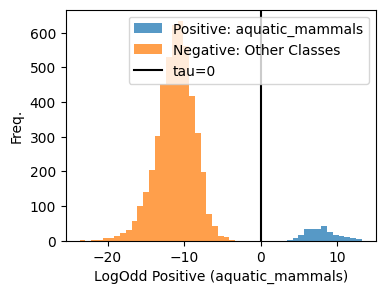

In [15]:
def compute_logit_distribution(model, verbose=False):
    dl =  dl_train

    arr_logits = []
    arr_y = []
    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        logit = model(x).cpu()
        arr_y.extend(y.detach().numpy().tolist())
        arr_logits.extend(logit.detach().numpy().tolist())

    arr_logits = np.array(arr_logits) 
    arr_y = np.array(arr_y)
    plt.figure(figsize=(4, 3))
    vmin, vmax = np.min(arr_logits), np.max(arr_logits)
    bins = np.linspace(vmin, vmax, 50)
    
    plt.hist(
        arr_logits[arr_y == 1],
        bins=bins,
        label=f"Positive: {SELECTED_GROUP}",
        alpha=0.75
    )
    plt.hist(
        arr_logits[arr_y == 0],
        bins=bins,
        label=f"Negative: Other Classes",
        alpha=0.75
    )
    tau = 0
    plt.axvline(tau, label=f"tau={tau}", color="black")
    plt.ylabel("Freq.")
    plt.xlabel(f"LogOdd Positive ({SELECTED_GROUP})")
    plt.legend()
    
compute_logit_distribution(model, verbose=True)    

# Extract Activation

## Output Quantities

In [16]:
class OutputQuantity:
    def __call__(self, logits, target_logits):
        raise NotImplementedError()
    def __str__(self):
        return self.__class__.__name__
        
class LogOddWinningClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(logits).detach() * logits

## Sample Selection Critieria

In [17]:
XXX = [1,2, 5,0]
XXX[-2:]

[5, 0]

In [18]:
class CriteriaSampleSelection:
    def __call__(self, logits: torch.Tensor):
        raise NotImplementedError("error")
    def slug(self) -> str:
        raise NotImplementedError("error")
class CriteriaSelectNSamples(CriteriaSampleSelection):
    
    def __init__(self, N: int, threshold=0, verbose=False):
        self.N = N
        
        arr_logits = extract_logits(model, dl=dl_train, verbose=verbose)
        self.total = arr_logits.shape[0]
        
        is_in_left_region = arr_logits < threshold
        is_in_right_region = arr_logits >= threshold


        self.criteria_left = np.sort(arr_logits[is_in_left_region])[-N]
        self.criteria_right = np.sort(arr_logits[is_in_right_region])[N]
        

    def __call__(self, logits):
        return (logits > self.criteria_left) * (logits <= self.criteria_right)
        
    def __str__(self):
        return f"SelectNSamples(N={self.N}, total={self.total}, [{self.criteria_left:.2f}, {self.criteria_right:.2f}])"
    def slug(self):
        return f"select-{self.N}"

class CriteriaSelectNSamplesOppositeSide(CriteriaSampleSelection):
    
    def __init__(self, N: int, threshold=0, verbose=False):
        self.N = N
        
        arr_logits = extract_logits(model, dl=dl_train, verbose=verbose)
        self.total = arr_logits.shape[0]
        
        is_in_left_region = arr_logits < threshold
        is_in_right_region = arr_logits >= threshold


        self.criteria_left = np.sort(arr_logits[is_in_left_region])[N]
        self.criteria_right = np.sort(arr_logits[is_in_right_region])[-N]
        

    def __call__(self, logits):
        return torch.logical_or(
            (logits < self.criteria_left),
            (logits >= self.criteria_right)
        )
        
    def __str__(self):
        return f"SelectNSamplesOppositeSide(N={self.N}, total={self.total}, [{self.criteria_left:.2f}, {self.criteria_right:.2f}])"
    def slug(self):
        return f"select-opposite-side-{self.N}"
        
class CriteriaSelectAllSamples(CriteriaSampleSelection):
    def __call__(self, logits):
        return torch.ones_like(logits).int().to(logits.device)
        
    def __str__(self):
        return f"SelectNSamples(N=∞)"

    def slug(self):
        return f"select-all"
    
def ano():
    arr_logits = extract_logits(model, dl=dl_train, verbose=True)

    arr_logits = torch.from_numpy(arr_logits)
    
    for N in [5, 10, 100]:
        
        criteria = CriteriaSelectNSamples(N=N)
    
        np.testing.assert_allclose(
            criteria(arr_logits).sum(),
            2*N
        )
        print(f"sanity check: {criteria} passed!")

    all_cri = CriteriaSelectAllSamples()
    all_cri(arr_logits)
    print(f"sanity check: {all_cri} passed!")

    print(f"sanity check: {CriteriaSelectNSamplesOppositeSide(N=10)(arr_logits)} passed!")
ano()

Extract Logits:   0%|          | 0/40 [00:00<?, ?it/s]

sanity check: SelectNSamples(N=5, total=5000, [-4.52, 4.29]) passed!
sanity check: SelectNSamples(N=10, total=5000, [-4.84, 4.92]) passed!
sanity check: SelectNSamples(N=100, total=5000, [-6.71, 7.33]) passed!
sanity check: SelectNSamples(N=∞) passed!
sanity check: tensor([False, False, False,  ..., False, False, False]) passed!


In [19]:
def extract_activation_context_for_task(
    model: nn.Module,
    layer: str,
    sample_selection_criteria=CriteriaSelectAllSamples(),
    data_loader=dl_train,
    seed=1,
    device=DEVICE,
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False
):

    arr_logodds = []
    arr_act = []
    arr_ctx = []

    rng = np.random.default_rng(seed=1)
    logodd_quantity = LogOddWinningClass()

    try:
        
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        
        for batch in tqdm(data_loader, desc=f"[layer={layer}] extract actctx (group={SELECTED_GROUP} (criteria={sample_selection_criteria} wrt {logodd_quantity})"):
            x, y = batch
            x = x.to(device)


            logits = model(x)
            
            arr_logodds = logodd_quantity(logits, y)
            
            (arr_logodds).sum().backward()
            act = utils.interceptor.get_output(module)

            assert act.grad is not None
            ctx = act.grad
            
            output_dimensions = act.shape[1:]

            assert ctx.shape == act.shape
            
            act = act.detach().cpu().numpy()
            ctx = ctx.detach().cpu().numpy()


            selected = sample_selection_criteria(arr_logodds).detach().cpu().numpy()
            if selected.sum() == 0:
                continue

            act = act[selected,:, :, :]
            ctx = ctx[selected,:, :, :]
        

            selected_act, selected_ctx = utils.subsample_tensors(
                act,
                ctx,
                num_locations=number_of_selected_spatial_locations,
                rng=rng,
            )
            

            arr_act.append(selected_act)
            arr_ctx.append(selected_ctx)

    finally:
        hook.remove()
        model.fc.task_id = None

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)
 
    return arr_act, arr_ctx


def ano():

    arr_act, arr_ctx = extract_activation_context_for_task(
        model, 
        "layer1",
        data_loader=dl_train,
    )
ano()

[layer=layer1] extract actctx (group=aquatic_mammals (criteria=SelectNSamples(N=∞) wrt LogOddWinningClass):   …

layer1: output-dims=torch.Size([64, 32, 32])


# Construct Basis

In [89]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs, sort_func(eigvals)


class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape
        cov = arr_act.T @ arr_act / N
        self.cov = cov
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class GradPCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape
        
        cov = arr_ctx.T @ arr_ctx / N
        self.cov = cov
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]
        
class PRCASortAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, self.eigvals = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCAPosDef(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        cov_a = (arr_act.T @ arr_act)
        cov_c = (arr_ctx.T @ arr_ctx)
        
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        alpha_a = 1/np.trace(cov_a) 
        alpha_c = 1/np.trace(cov_c)
        alpha_acca = np.sqrt(alpha_a * alpha_c)
        
        cov = (2*alpha_a)*cov_a \
            + (2*alpha_c)*cov_c  \
            + alpha_acca * cov_ac
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCAPosDefNormalizedAlphaACCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        cov_a = (arr_act.T @ arr_act)
        cov_c = (arr_ctx.T @ arr_ctx)
        
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        alpha_a = 1/np.trace(cov_a) 
        alpha_c = 1/np.trace(cov_c)
        alpha_acca = np.sqrt(alpha_a * alpha_c)

        
        
        cov = (2*alpha_a)*cov_a \
            + (2*alpha_c)*cov_c  \
            + alpha_acca * cov_ac

        cov = cov / alpha_acca
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCAPosDefNormalizationWithBeta(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        cov_a = (arr_act.T @ arr_act)
        cov_c = (arr_ctx.T @ arr_ctx)
        
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        beta_a = 1/np.trace(cov_a) 
        beta_c = 1/np.trace(cov_c)
        beta_acca = np.sqrt(beta_a * beta_c)
        
        cov = (beta_a + beta_acca)*cov_a \
            + (beta_c + beta_acca)*cov_c  \
            + beta_acca * cov_ac
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]




class PRCAPosDefNormalizationWithBetaV2(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        # this is equivalent to PRCAPosDef
        # normalize arr_act and arr_ctx before
        # equivalently, this is equal to setting all beta to zero.
        arr_act = arr_act / np.sqrt(np.trace(arr_act.T @ arr_act))
        arr_ctx = arr_ctx / np.sqrt(np.trace(arr_ctx.T @ arr_ctx))
        
        cov_a = (arr_act.T @ arr_act)
        cov_c = (arr_ctx.T @ arr_ctx)
        
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        
        cov = 2 * cov_a + 2 * cov_c + cov_ac
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]



class PRCAPosDefNormalizationWithLargestEigval(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        # this is equivalent to PRCAPosDef
        # normalize arr_act and arr_ctx before
        # equivalently, this is equal to setting all beta to zero.
        arr_act = arr_act / np.max(np.linalg.eigvalsh(arr_act.T @ arr_act)) ** 0.5
        arr_ctx = arr_ctx / np.max(np.linalg.eigvalsh(arr_ctx.T @ arr_ctx)) ** 0.5
        
        cov_a = (arr_act.T @ arr_act)
        cov_c = (arr_ctx.T @ arr_ctx)
        
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        
        cov = 2 * cov_a + 2 * cov_c + cov_ac
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCAPosDefNormalizationUnitNorm(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        # normalize arr_act and arr_ctx to be have unit norm
        arr_act = arr_act / np.linalg.norm(arr_act, axis=1, keepdims=1)
        arr_ctx = arr_ctx / np.linalg.norm(arr_ctx, axis=1, keepdims=1)
        
        cov_a = (arr_act.T @ arr_act)
        cov_c = (arr_ctx.T @ arr_ctx)
        
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        
        cov = 2 * cov_a + 2 * cov_c + cov_ac
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

        
class PRCAPosDefWithoutNormalization(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        
        cov_a = (arr_act.T @ arr_act)
        cov_c = (arr_ctx.T @ arr_ctx)
        
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        
        cov = 2 * cov_a + 2 * cov_c + cov_ac
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]



def ano():
    # return
    for lix in range(1, 4+1):
        layer = f"layer{lix}"
        arr_act, arr_ctx = extract_activation_context_for_task(
            model, 
            layer,
            data_loader=dl_train,
        )
        N, _ = arr_act.shape

        print(f"------ [layer={layer}] ------")

        for unit_norm in [False, True]:
            if unit_norm:
                arr_act = arr_act / np.linalg.norm(arr_act, axis=1, keepdims=1)
                arr_ctx = arr_ctx / np.linalg.norm(arr_ctx, axis=1, keepdims=1)

            print(f"####### unit_norm={unit_norm} ########")
            
            cov_a = (arr_act.T @ arr_act)
            cov_c = (arr_ctx.T @ arr_ctx)
        
            alpha_a = 1/np.trace(cov_a)
            alpha_c = 1/np.trace(cov_c)
        
            beta_a = alpha_a
            beta_c = alpha_c
            beta_acca = np.sqrt(alpha_a * alpha_c)
    
            E_norm_a_squared = np.mean(np.linalg.norm(arr_act, axis=1) ** 2)
            print(f"E_norm_a_squared={E_norm_a_squared:.4e}  | np.trace(cov_a)={np.trace(cov_a / N):.4e}")
            
            # print(f"alpha_a={alpha_a:.4e}")
            # print(f"alpha_c={alpha_c:.4e}")
            # print(f"Coeff SigmaACCA: beta_acca={beta_acca:.4e}")
            # print(f"Coeff    SigmaA: 2alpha_a={2*alpha_a:.4e}  |  (beta_a+beta_acca)={beta_a+beta_acca:.4e}")
            # print(f"Coeff    SigmaC: 2alpha_c={2*alpha_c:.4e}  |  (beta_c+beta_acca)={beta_c+beta_acca:.4e}")
    
            print("+++++++ normalized by beta_acca ++++++")
            print(f"Coeff SigmaACCA: beta_acca={beta_acca/beta_acca:.4e}")
            print(f"Coeff    SigmaA: 2alpha_a={2*alpha_a/beta_acca:.4e}  |  (beta_a+beta_acca)={(beta_a+beta_acca)/beta_acca:.4e}")
            print(f"Coeff    SigmaC: 2alpha_c={2*alpha_c/beta_acca:.4e}  |  (beta_c+beta_acca)={(beta_c+beta_acca)/beta_acca:.4e}")
        print("==============================")
# ano()

In [21]:
raise

RuntimeError: No active exception to reraise

# Estimate Performance

In [90]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_aurocs_at_k(
    model, layer, 
    arr_ks,
    arr_basis_names=[
        PCA
    ],
    
):
    arr_act, arr_ctx = extract_activation_context_for_task(
        model=model, 
        layer=layer, 
    )
    
    module = getattr(model, layer)

    arr_dfs = []
    for basis_class in arr_basis_names:
        arr_stat_rows = []

        basis: BasisInterface = basis_class(
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
            layer=layer,
        )
        basis_name = basis_class.__name__

        for k in tqdm(
            arr_ks,
            desc=f"[{basis_name:>20s}] Estimating Performance"
        ):
        
            if ("-k" in basis_name) and not f"{k}" == basis_name.split("k")[1]:
                continue

            Uk = basis.get_Uk(k=k)

            row = dict(
                data_group=SELECTED_GROUP,
                layer=layer,
                k=k,
                basis_name=basis_name,
            )

            Uk = torch.from_numpy(Uk).float().to(DEVICE)

            arr_hooks = []
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                arr_hooks.append(hook)
    
                for label, dl in [
                    # ("train", dl_train),
                    ("val", dl_val)
                ]:
                    row[f"{label}_auroc"] = compute_performance(model)
                
            finally:
                for hook in arr_hooks:
                    hook.remove()

            if hasattr(basis, "is_slow"):
                print(f"k={k}", row)
            arr_stat_rows.append(row)
            
     
        df = pd.DataFrame(arr_stat_rows)

        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", f"val_auroc"], ascending=[True, False])
    
    return df

compute_task_aurocs_at_k(
    model, layer="layer4", 
    arr_basis_names=[
        # PCA,
        # GradPCA,     
        # PRCASortAbs,
        PRCAPosDef,
        # PRCAPosDefNormalizedAlphaACCA,
        # PRCAPosDefNormalizationWithBeta,
        # PRCAPosDefNormalizationWithBetaV2,
        # PRCAPosDefNormalizationUnitNorm
        # PRCAPosDefWithoutNormalization,
        PRCAPosDefNormalizationWithLargestEigval
    ],
    arr_ks=[1, 5, 20],
)

[layer=layer4] extract actctx (group=aquatic_mammals (criteria=SelectNSamples(N=∞) wrt LogOddWinningClass):   …

layer4: output-dims=torch.Size([512, 4, 4])


[          PRCAPosDef] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[PRCAPosDefNormalizationWithLargestEigval] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

,data_group,layer,k,basis_name,val_auroc
0,aquatic_mammals,layer4,1,PRCAPosDefNormalizationWithLargestEigval,0.539948
0,aquatic_mammals,layer4,1,PRCAPosDef,0.516947
1,aquatic_mammals,layer4,5,PRCAPosDefNormalizationWithLargestEigval,0.971804
1,aquatic_mammals,layer4,5,PRCAPosDef,0.970057
2,aquatic_mammals,layer4,20,PRCAPosDefNormalizationWithLargestEigval,0.961251
2,aquatic_mammals,layer4,20,PRCAPosDef,0.961013


## Estimate Statistics

In [91]:
LAYER_DIM_MAPPING = utils.get_dimensions_at_layers(model, dl_train, ["layer1", "layer2", "layer3", "layer4"], device=DEVICE)

In [92]:
ARR_BASIS_CLASSES = [
    PRCAPosDef,
    PRCAPosDefNormalizationWithLargestEigval,
]

def estimate_stats(
    arr_basis_names=ARR_BASIS_CLASSES
):
    arr_dfs = []
    arr_layers = ["layer1", "layer2", "layer3", "layer4"]
    for layer in tqdm(arr_layers):
        d = LAYER_DIM_MAPPING[layer]
        arr_ks = np.linspace(1, 32, 10).astype(int)

        df = compute_task_aurocs_at_k(
            model, layer=layer, 
            arr_basis_names=arr_basis_names,
            arr_ks=arr_ks,
        )
        arr_dfs.append(df)

    return pd.concat(arr_dfs)

df_stats_all_samples = estimate_stats()

  0%|          | 0/4 [00:00<?, ?it/s]

[layer=layer1] extract actctx (group=aquatic_mammals (criteria=SelectNSamples(N=∞) wrt LogOddWinningClass):   …

layer1: output-dims=torch.Size([64, 32, 32])


[          PRCAPosDef] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[PRCAPosDefNormalizationWithLargestEigval] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

...

[PRCAPosDefNormalizationWithLargestEigval] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[layer=layer4] extract actctx (group=aquatic_mammals (criteria=SelectNSamples(N=∞) wrt LogOddWinningClass):   …

layer4: output-dims=torch.Size([512, 4, 4])


[          PRCAPosDef] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[PRCAPosDefNormalizationWithLargestEigval] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

In [93]:
df_stats_all_samples

,data_group,layer,k,basis_name,val_auroc
0,aquatic_mammals,layer1,1,PRCAPosDefNormalizationWithLargestEigval,0.500053
0,aquatic_mammals,layer1,1,PRCAPosDef,0.500000
1,aquatic_mammals,layer1,4,PRCAPosDef,0.587782
1,aquatic_mammals,layer1,4,PRCAPosDefNormalizationWithLargestEigval,0.537199
2,aquatic_mammals,layer1,7,PRCAPosDef,0.864315
...,...,...,...,...,...
7,aquatic_mammals,layer4,25,PRCAPosDefNormalizationWithLargestEigval,0.956315
8,aquatic_mammals,layer4,28,PRCAPosDefNormalizationWithLargestEigval,0.952233
8,aquatic_mammals,layer4,28,PRCAPosDef,0.951420
9,aquatic_mammals,layer4,32,PRCAPosDefNormalizationWithLargestEigval,0.952024


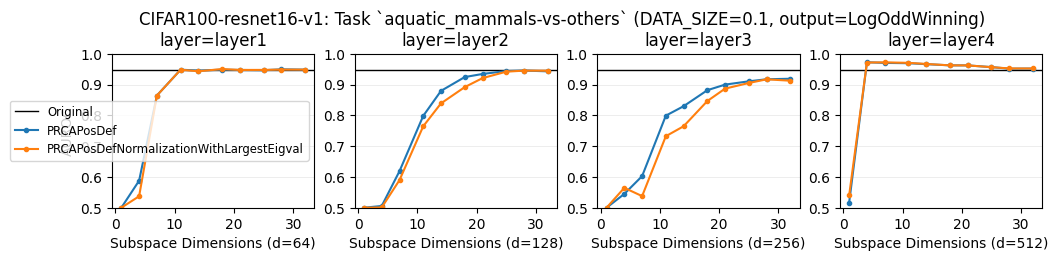

In [95]:
def viz(
    df, 
    arr_basis_names,
):

    arr_layers = df.layer.unique()
    ncols = len(arr_layers)
    
    plt.figure(figsize=(3*ncols, 2))
    plt.suptitle(
        f"CIFAR100-resnet16-v1: Task `{SELECTED_GROUP}-vs-others` (DATA_SIZE={DATA_SIZE}, output=LogOddWinning)", 
        y=1.1
    )
    cmap=mpl.colormaps["Blues"]


    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        plt.ylim([0.5, 1])
        plt.title(f"layer={layer}")
        
        d = LAYER_DIM_MAPPING[layer]

        for six, basis_name in enumerate(arr_basis_names):
            
            _df = df[
                (df.basis_name == basis_name) \
                    & (df.layer==layer)
            ]
            
            assert _df.shape[0] > 0
            if six == 0:
                plt.axhline(ref_performance, label="Original", color="k", lw=1, ls="-")
                for v in [0.5, 0.6, 0.7, 0.8, 0.9]:
                    plt.axhline(v, lw=0.5, ls="-", alpha=0.1, color="k")
            
            plt.plot(
                _df.k,
                _df.val_auroc,
                marker=".",
                label=f"{basis_name}",
            )

        if lix == 0:
            plt.ylabel("AUROC")
            plt.legend(fontsize="small")
        plt.xlabel(f"Subspace Dimensions (d={d})")
        
viz(
    df_stats_all_samples,
    arr_basis_names = [c.__name__ for c in ARR_BASIS_CLASSES],
)

In [ ]:
print(f"Finished at {datetime.now()}")